In [16]:
from pathlib import Path
from puprisa.core.pps import PPS
import matplotlib.pyplot as plt

In [17]:
# %load_ext autoreload
# %autoreload 2

# Example usage of PPS functionality

Import DukeScan file

In [18]:
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
path = ROOT / "data" / "melanin_DS_CH1.tif"    
stack = PPS.load(path)
stack.filename = 'Melanin'

## Visualization
Show plot of average TA curve and projected stack

<Axes: title={'center': 'Melanin'}, xlabel='Time delay (ps)', ylabel='Average signal (a.u.)'>

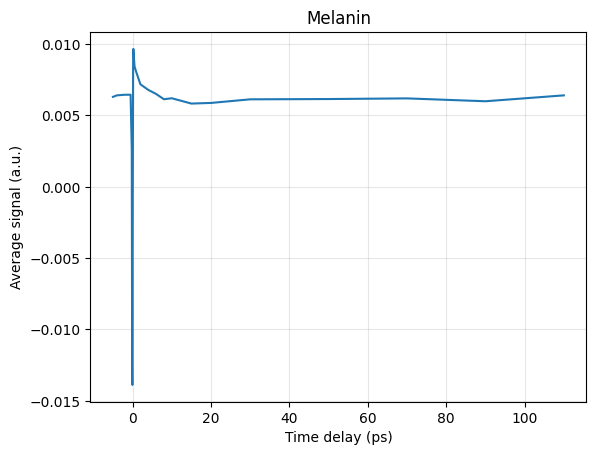

In [19]:
stack.plot_average_curve()

<Axes: title={'center': 'Melanin - projection'}>

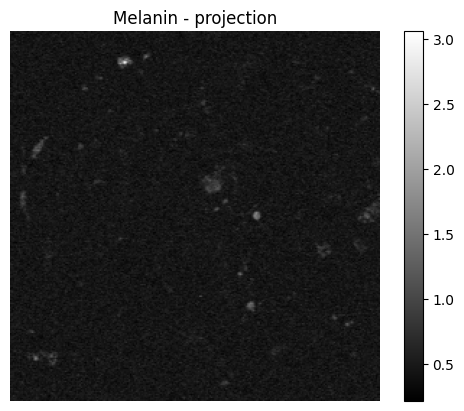

In [20]:
stack.plot_projection()

## Processing

### Subtracting the mean of the first few images and downsampling

<Axes: title={'center': 'Melanin'}, xlabel='Time delay (ps)', ylabel='Average signal (a.u.)'>

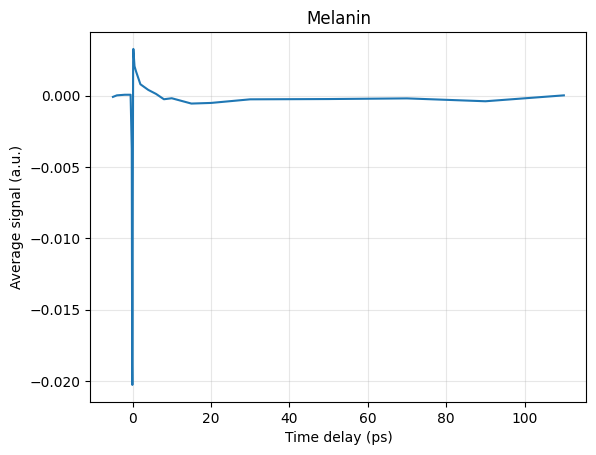

In [21]:
stack.apply_background_subtraction(indices=range(3), pixelwise=True)
stack.plot_average_curve()

<Axes: title={'center': 'Melanin - projection'}>

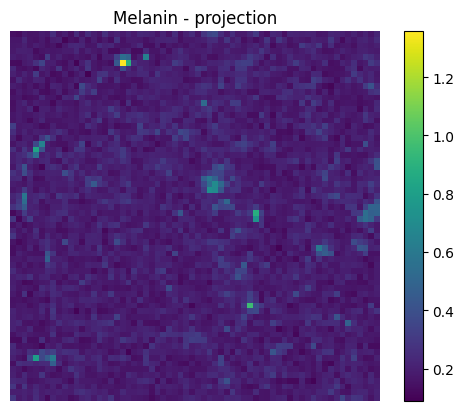

In [22]:
downsampled_stack = stack.downsample(factor=4)
downsampled_stack.plot_projection(colormap = "viridis")

### intensity threshold

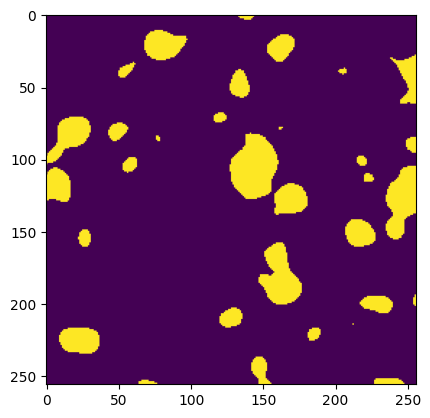

In [23]:
stack.create_mask_from_threshold()
plt.imshow(stack.mask)
plt.show()

<Axes: title={'center': 'Melanin - projection'}>

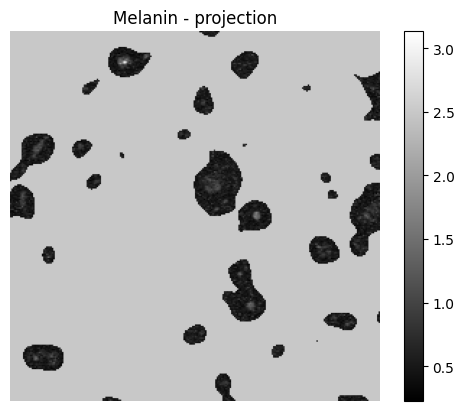

In [24]:
stack.plot_projection()

### derive substacks

In [25]:
substacks = stack.substacks(128)
print(f"Number of substacks: {len(substacks)}")

Number of substacks: 4


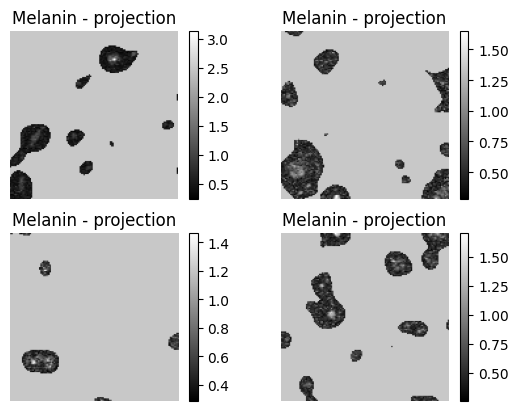

In [26]:
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()
for i, substack in enumerate(substacks):
    substack.plot_projection(ax=axes[i])

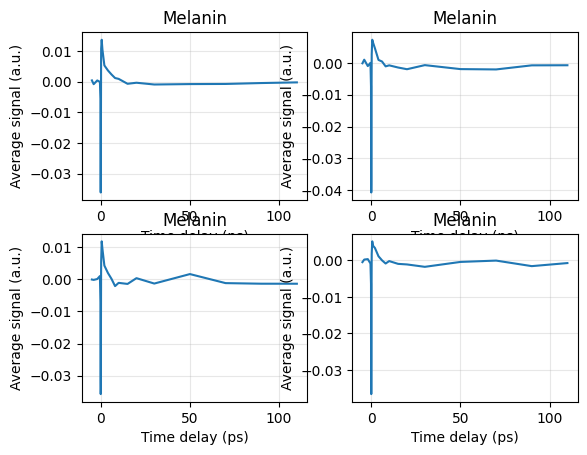

In [27]:
fig, ax = plt.subplots(2, 2)
ax = ax.flatten()
for i, substack in enumerate(substacks):
    ax[i].set_title(f"Substack {i+1}")
    substack.plot_average_curve(ax=ax[i])

### Phasor

<Axes: title={'center': 'Phasor @ 0.25 THz'}, xlabel='g', ylabel='s'>

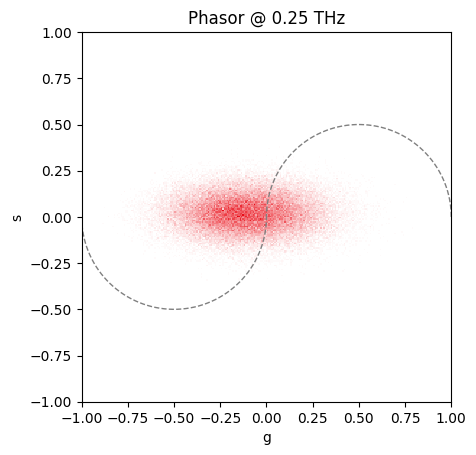

In [28]:
stack.plot_phasor(color_hex = "#e8000b", freq = 0.25, use_mask = False)